<h1><center>Laboratorio 7: Ensamblaje, Optimización de Hiperparámetros e Interpretabilidad 🤖</center></h1>

<center><strong>MDS7202: Laboratorio de Programación Científica para Ciencia de Datos</strong></center>

---

### Cuerpo Docente

- Profesores: Pablo Badilla y Diego Cortez
- Auxiliares: Valentina Rojas y Melanie Peña
- Ayudantes: Javiera Arévalo, Tamara Carrasco y Ignacio Reyes

### Equipo: SUPER IMPORTANTE - notebooks sin nombre no serán revisados

- Nombre de alumno 1: Leonardo Navarro
- Nombre de alumno 2: Matias Sweet

---

### Reglas

- **Grupos de 2 personas**
- Cualquier duda fuera del horario de clases al foro. Mensajes al equipo docente serán respondidos por este medio.
- Prohibido copiar.
- Uso de LLM (Copilot, Claude, Antigravity, Cursor, etc.) restringido a consultas, documentación y corrección de errores.

## Temas a tratar

- Ensamblaje: Bagging (`RandomForest`), Boosting (`XGBoost`, `LightGBM`) y Stacking.
- Optimización de Hiperparámetros con `Optuna` y visualización interactiva con `optuna-dashboard`.
- Interpretabilidad global: `Permutation Feature Importance (PFI)`.
- Interpretabilidad local: `SHAP`.

### Objetivos principales del laboratorio

- Aplicar y comparar métodos de ensamblaje sobre un problema de clasificación de texto.
- Optimizar hiperparámetros de LightGBM usando Optuna y visualizar el proceso con `optuna-dashboard`.
- Interpretar las predicciones del modelo usando PFI y SHAP.

El laboratorio deberá ser desarrollado sin el uso indiscriminado de iteradores nativos de Python (aka "for", "while"). La idea es que aprendan a exprimir al máximo las funciones optimizadas que nos entrega `pandas`.

### Instalamos librerías 😸

In [1]:
!uv add nltk lightgbm xgboost optuna shap scikit-learn plotly

Resolved 153 packages in 1ms
Checked 145 packages in 15ms


In [2]:
import warnings

import nltk
import optuna
import pandas as pd
import plotly.express as px
import shap
from lightgbm import LGBMClassifier
from nltk import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
from optuna.visualization import (
    plot_optimization_history,
    plot_parallel_coordinate,
    plot_param_importances,
)
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import RandomForestClassifier, StackingClassifier
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, f1_score
from sklearn.model_selection import StratifiedKFold, cross_val_score, train_test_split  # noqa: F401
from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier

warnings.filterwarnings("ignore")

nltk.download("stopwords", quiet=True)
nltk.download("punkt", quiet=True)
nltk.download("punkt_tab", quiet=True)

RANDOM_STATE = 42
optuna.logging.set_verbosity(optuna.logging.WARNING)

e:\Equipo\Mati\Escritorio\MDS7202\MDS7202\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# 1. ¿Quién es Bat Cow?

<p align="center">
  <img src="https://i.imgur.com/D9f1RHy.jpg" width="350">
</p>

En vez de estar desarrollando las evaluaciones correspondientes a su curso, su profesor de catedra y su auxiliar discuten acerca la alineación (i.e., si es heroe o villano) del personaje de ficción Bat-Cow.

El cuerpo docente, no logra ponerse de acuerdo si el personaje es bueno, neutral o malo: el auxiliar plantea que Bat-cow posee una siniestra mirada, intrigante pero común característica de los personajes malvados.
Por otra parte, extendiendo las ideas de Rousseau, el profesor plantea que tal como los humanos no nacen malos, no existe motivo por el cual una vaca con superpoderes deba serlo.

Sin embargo, ambos concuerdan que es difícil estimar la alineación solo usando los atributos físicos. Es por esto que les solicitan construir y optimizar un clasificador basado en texto que analice la alineación de cada personaje basado en su historia personal.

Para este laboratorio deben trabajar con los datos `df_comics.csv` y `comics_no_label.csv` subidos a u-cursos.

In [3]:
df_comics = pd.read_csv("df_comics.csv", index_col=0)
df_comics_no_label = pd.read_csv("comics_no_label.csv", index_col=0)
df_comics = df_comics.dropna(subset=["history_text"])
df_comics

,name,real_name,full_name,overall_score,history_text,powers_text,intelligence_score,strength_score,speed_score,durability_score,...,has_flight,has_accelerated_healing,has_weapons_master,has_intelligence,has_reflexes,has_super_speed,has_durability,has_stamina,has_agility,has_super_strength
0,3-D Man,"Delroy Garrett, Jr.","Delroy Garrett, Jr.",6,"Delroy Garrett, Jr. grew up to become a track ...",NaN,85,30,60,60,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
2,A-Bomb,Richard Milhouse Jones,Richard Milhouse Jones,20,"Richard ""Rick"" Jones was orphaned at a young ...","On rare occasions, and through unusual circu...",80,100,80,100,...,0.0,1.0,0.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0
3,Aa,Aa,NaN,12,Aa is one of the more passive members of the P...,NaN,80,50,55,45,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,Aaron Cash,Aaron Cash,Aaron Cash,5,Aaron Cash is the head of security at Arkham A...,NaN,80,10,25,40,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5,Aayla Secura,Aayla Secura,NaN,8,ayla Secura was a Rutian Twi'lek Jedi Knight (...,NaN,90,40,45,55,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1445,Zatanna,Zatanna Zatara,Zatanna Zatara,10,Zatanna is the daughter of adventurer John Zat...,Zatanna is genetically talented with her magi...,90,10,25,30,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1446,Zero,DWN-∞: Zero,DWN-∞: Zero,18,Zero was created by the late Dr. Albert Wily ...,NaN,80,100,100,100,...,0.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
1447,Zoom (New 52),Hunter Zolomon,NaN,20,"Hunter Zolomon is better known as Zoom, a spee...",After tricking Barry Allen and Wally West into...,95,50,100,75,...,0.0,1.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
1448,Zoom,Hunter Zolomon,Hunter Zolomon,9,Hunter Zolomon had a troubled relationship wi...,"Zoom is able to alter time, to make himself ev...",75,10,100,30,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0


## 1.1 Obtención de Features y Bag of Words

<p align="center">
  <img src="https://media0.giphy.com/media/eIUpSyzwGp0YhAMTKr/200.gif" width="300">
</p>

`bag of words` es un modelo de conteo utilizado en NLP que genera una representación vectorial para cada documento a través del conteo de las palabras que contienen.

<p align="center">
  <img src="https://user.oc-static.com/upload/2020/10/23/16034397439042_surfin%20bird%20bow.png" width="500">
</p>

Para facilitar el conteo transformamos cada documento en un vector mediante **tokenización**:

In [4]:
docs = ["The teacher rocks like a good rock & roll", "the rock is the best actor in the world"]
docs_tokenizados = [word_tokenize(doc) for doc in docs]
docs_tokenizados

[['The', 'teacher', 'rocks', 'like', 'a', 'good', 'rock', '&', 'roll'],
 ['the', 'rock', 'is', 'the', 'best', 'actor', 'in', 'the', 'world']]

Podemos mejorar la tokenización con:

- **Stemming**: transforma palabras a su forma raíz (*running → run*, *rocks → rock*).
- **Eliminación de Stopwords**: elimina palabras muy frecuentes que entorpecen la clasificación (*the*, *is*, *a*, ...).

<p align="center">
  <img src="https://devopedia.org/images/article/218/8583.1569386710.png" width="300">
</p>

In [5]:
stop_words = stopwords.words("english")


class StemmerTokenizer:
    def __init__(self):
        self.ps = PorterStemmer()

    def __call__(self, doc):
        doc_tok = word_tokenize(doc)
        doc_tok = [t for t in doc_tok if t not in stop_words]
        return [self.ps.stem(t) for t in doc_tok]


tokenizador = StemmerTokenizer()

docs = [
    "The teacher rocks like a good rock & roll",
    "the rock is the best actor in the world",
    "New York is a beautiful city",
]

print("Con StemmerTokenizer:")
print([tokenizador(doc) for doc in docs])
print("\nSin preprocesamiento:")
print([word_tokenize(doc) for doc in docs])

Con StemmerTokenizer:
[['the', 'teacher', 'rock', 'like', 'good', 'rock', '&', 'roll'], ['rock', 'best', 'actor', 'world'], ['new', 'york', 'beauti', 'citi']]

Sin preprocesamiento:
[['The', 'teacher', 'rocks', 'like', 'a', 'good', 'rock', '&', 'roll'], ['the', 'rock', 'is', 'the', 'best', 'actor', 'in', 'the', 'world'], ['New', 'York', 'is', 'a', 'beautiful', 'city']]


#### Al Estilo Scikit

Scikit implementa `bag of words` con `CountVectorizer()`. Además soporta **n-gramas**: secuencias contiguas de n palabras que se tratan como un único token. Esto permite capturar contexto local que los unigramas pierden.

| Tipo | n | Tokens de `"nueva york ciudad"` |
|------|---|--------------------------------|
| Unigrama | 1 | `nueva`, `york`, `ciudad` |
| Bigrama | 2 | `nueva york`, `york ciudad` |
| Trigrama | 3 | `nueva york ciudad` |

Con `ngram_range=(1,2)` el vectorizador incluye **unigramas y bigramas** simultáneamente. Los bigramas son especialmente útiles para capturar expresiones compuestas como `bat cow`, `spider man` o `super hero` que pierden su significado si se separan.

El parámetro `max_features` limita el vocabulario a los n tokens más frecuentes, controlando la dimensionalidad de la representación.

In [6]:
bow = CountVectorizer(tokenizer=StemmerTokenizer(), ngram_range=(1, 2))
df_bow = bow.fit_transform(docs)
pd.DataFrame(df_bow.toarray(), columns=bow.get_feature_names_out())

,&,& roll,actor,actor world,beauti,beauti citi,best,best actor,citi,good,...,rock,rock &,rock best,rock like,roll,teacher,teacher rock,world,york,york beauti
0,1,1,0,0,0,0,0,0,0,1,...,2,1,0,1,1,1,1,0,0,0
1,0,0,1,1,0,0,1,1,0,0,...,1,0,1,0,0,0,0,1,0,0
2,0,0,0,0,1,1,0,0,1,0,...,0,0,0,0,0,0,0,0,1,1


#### Combinando Features: `ColumnTransformer`

Para combinar en un solo paso el preprocesamiento de texto y numérico, usamos `ColumnTransformer`. Este aplica transformadores distintos a subconjuntos de columnas del DataFrame y concatena el resultado en una sola matriz de features lista para entrenar.

<p align="center">
  <img src="https://c.tenor.com/LkQzw7k5DV4AAAAd/anime-hacking.gif" width="300">
</p>

El `preprocessing_transformer` que usaremos a lo largo del lab combina:

- **`CountVectorizer`** con `StemmerTokenizer`, `ngram_range=(1,2)` y `max_features=500` → aplicado sobre la columna `history_text`.
- **`MinMaxScaler`** → aplicado sobre los 6 atributos numéricos de habilidad: `intelligence_score`, `strength_score`, `speed_score`, `durability_score`, `power_score`, `combat_score`.

In [7]:
preprocessing_transformer = ColumnTransformer(
    transformers=[
        (
            "MinMaxScaler",
            MinMaxScaler(),
            [
                "intelligence_score",
                "strength_score",
                "speed_score",
                "durability_score",
                "power_score",
                "combat_score",
            ],
        ),
        (
            "bow",
            CountVectorizer(
                tokenizer=StemmerTokenizer(),
                max_features=500,
                ngram_range=(1, 2),
            ),
            "history_text",
        ),
    ]
)

## 1.2 Diseño de Baseline y Primer Entrenamiento [1 Punto]

<p align="center">
  <img src="https://pa1.narvii.com/6374/9eaec1b7bf9157334151452a669516f9a78b954c_hq.gif" width="300">
</p>

### 1.2.1 ¿Qué es un Baseline? [0.2 Puntos]

Antes de entrenar modelos complejos, es fundamental establecer un punto de referencia mínimo. Responde las siguientes preguntas con tus propias palabras:

1. **¿Qué es un baseline en Machine Learning?** ¿Para qué sirve establecerlo antes de evaluar modelos más sofisticados?
2. **¿Por qué usamos un `DummyClassifier` como baseline?** ¿Qué implica que un modelo "real" no logre superar su rendimiento?

> **Respuesta:**

Un baseline es un modelo o heurística muy simple que se usa como punto de comparación frente al resto de los modelos. Su función es fijar un piso de rendimiento: cualquier modelo más complejo debería superarlo con claridad para que se justifique su mayor costo computacional, su mayor riesgo de sobreajuste y su menor interpretabilidad. Sin baseline no hay forma honesta de saber si un buen número de accuracy o F1 refleja aprendizaje real o si solo está reflejando la frecuencia de la clase mayoritaria.
El DummyClassifier se usa como baseline porque genera predicciones sin mirar las features: solo aplica una regla fija (predecir la clase mayoritaria, una etiqueta aleatoria, o muestrear según la distribución del train, entre otras). Esa propiedad lo vuelve una referencia limpia, porque cualquier desempeño que lo supere solo puede venir del hecho de que el modelo real está extrayendo información de las variables de entrada. Si un modelo entrenado no logra superarlo, significa que sus predicciones no están explotando ninguna señal útil en las features: o bien las variables no son informativas para el problema, o bien el modelo no logra capturar la relación que existe entre ellas y el target.

---

### 1.2.2 Implementación [0.6 Puntos]

Genere un `Pipeline` con las características de 1.1 y un `DecisionTreeClassifier()` por defecto.

Separe el dataset en entrenamiento/prueba (80/20, estratificado, `random_state=RANDOM_STATE`). Entrene, reporte `classification_report` y compare con un `DummyClassifier(strategy="stratified")`.

**To-do:**
- [ ] Pipeline con preprocesamiento → `DecisionTreeClassifier`.
- [ ] Holdout estratificado 80/20.
- [ ] `classification_report` del baseline.
- [ ] Entrenar `DummyClassifier` y comparar.

In [8]:
# Separación de features (X) y target (y)
X = df_comics.drop(columns=["alignment"])
y = df_comics["alignment"]

# Holdout estratificado 80/20
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE)

# Pipeline con Preprocesamiento y DecisionTreeClassifier
pipe_dt = Pipeline(
    [("preprocessor", preprocessing_transformer), ("clf", DecisionTreeClassifier(random_state=RANDOM_STATE))]
)

# Entrenamiento y evaluación del Modelo Real
pipe_dt.fit(X_train, y_train)
y_pred_dt = pipe_dt.predict(X_test)

print(" Classification Report: Decision Tree ")
print(classification_report(y_test, y_pred_dt))

# Pipeline con DummyClassifier (Baseline)
pipe_dummy = Pipeline(
    [
        ("preprocessor", preprocessing_transformer),
        ("clf", DummyClassifier(strategy="stratified", random_state=RANDOM_STATE)),
    ]
)

# Entrenamiento y evaluación del Baseline
pipe_dummy.fit(X_train, y_train)
y_pred_dummy = pipe_dummy.predict(X_test)

print(" Classification Report: Dummy Classifier ")
print(classification_report(y_test, y_pred_dummy))

 Classification Report: Decision Tree 
              precision    recall  f1-score   support

         Bad       0.41      0.43      0.42        86
        Good       0.66      0.61      0.64       148
     Neutral       0.10      0.13      0.11        23

    accuracy                           0.51       257
   macro avg       0.39      0.39      0.39       257
weighted avg       0.53      0.51      0.52       257

 Classification Report: Dummy Classifier 
              precision    recall  f1-score   support

         Bad       0.32      0.34      0.33        86
        Good       0.58      0.56      0.57       148
     Neutral       0.12      0.13      0.12        23

    accuracy                           0.45       257
   macro avg       0.34      0.34      0.34       257
weighted avg       0.46      0.45      0.45       257



### 1.2.3 Pregunta de Cierre [0.2 Puntos]

**Pregunta:** ¿El `DecisionTreeClassifier` supera al `DummyClassifier`? ¿Qué concluyes de esto sobre lo que ha aprendido el modelo? Además responde:

1. ¿Por qué el accuracy puede ser una métrica engañosa en este problema? ¿Qué métrica es más apropiada si las clases están desbalanceadas?
2. ¿Por qué se usa el parámetro `stratify` en el `train_test_split`? ¿Qué problema evitamos al usarlo?
3. ¿Es mejor el clasificador que su versión aleatoria? ¿Podemos avanzar con confianza de que estamos clasificando mejor que si por ejemplo, tiraramos un dado con 3 caras?

> **Respuesta:**

Sí, el DecisionTreeClassifier supera al DummyClassifier: F1-Macro de 0.39 vs 0.34 y accuracy de 0.51 vs 0.45. El árbol está captando algún patrón en las features (palabras y scores numéricos) que va más allá de adivinar según la distribución de clases. Aun así, el desempeño global es bajo, sobre todo en "Neutral", donde el Dummy incluso logra un F1 marginalmente mejor (0.12 vs 0.11), un árbol simple no tiene cómo levantar una clase tan minoritaria.

Las clases están bastante desbalanceadas (Good: 148, Bad: 86, Neutral: 23). Por eso el accuracy es engañoso: un modelo que prediga siempre "Good" acertaría cerca del 57% sin haber aprendido nada útil sobre villanos ni neutrales. El F1-Macro es más informativo en este caso porque promedia el rendimiento por clase de forma equitativa, así que castiga al modelo cuando ignora a las minoritarias.
Con solo ~23 ejemplos de "Neutral" en el test (y pocos más en total), un split aleatorio sin stratify podría dejar el train casi sin ejemplos de esa clase, o vaciar el test, distorsionando la evaluación. Usar stratify mantiene la proporción Good/Bad/Neutral tanto en train como en test.

Sobre la última pregunta: sí, mejora respecto a la versión aleatoria. El Dummy estratificado equivale a tirar un dado de 3 caras sesgado por la frecuencia de cada clase, y aun así el árbol lo supera. El rendimiento sigue siendo modesto (F1-Macro 0.39), pero confirma que hay señal extraíble en los datos. Eso justifica probar con modelos más complejos (Bagging, Boosting).

---

# 2. Métodos de Ensamblaje [2 Puntos]

<p align="center">
  <img src="https://media.giphy.com/media/l0HlHFRbmaZtBRhXG/giphy.gif" width="300">
</p>

Los métodos de ensamblaje combinan múltiples modelos para obtener predicciones más robustas. Exploraremos tres estrategias:

| Estrategia | Idea clave | Ejemplo |
|------------|-----------|---------|
| **Bagging** | Modelos en paralelo sobre subconjuntos aleatorios | Random Forest |
| **Boosting** | Modelos en secuencia, cada uno corrige al anterior | XGBoost, LightGBM |
| **Stacking** | Predicciones de modelos base como input de un meta-modelo | StackingClassifier |

Todos usarán el mismo `preprocessing_transformer` de la sección 1.

## 2.1 Bagging: Random Forest [0.5 Puntos]

### 2.1.1 Descripción del algoritmo [0.2 Puntos]

Describe con tus propias palabras cómo funciona el **Bagging (Bootstrap Aggregating)**. La descripción debe cubrir los siguientes tres pasos:

1. **Generación de subconjuntos**: ¿Cómo se obtienen los subconjuntos de entrenamiento a partir del dataset original? ¿Se usa todo el dataset en cada uno? ¿Se pueden repetir instancias?
2. **Entrenamiento**: ¿Qué se entrena sobre cada subconjunto? ¿Los modelos se entrenan de forma dependiente o independiente entre sí?
3. **Agregación**: ¿Cómo se combinan las predicciones de todos los modelos para obtener una respuesta final?

> **Respuesta:**


Generación de subconjuntos: Bagging (Bootstrap Aggregating) construye varios subconjuntos de entrenamiento muestreando con reemplazo desde el dataset original. Cada subconjunto tiene el mismo tamaño que el dataset original, pero al permitirse el reemplazo, una instancia puede aparecer repetida varias veces en un mismo subconjunto y otras quedan fuera. En promedio, cada bootstrap contiene cerca del 63.2% de las instancias únicas, y el ~36.8% restante (Out-of-Bag) no es visto por ese modelo. Esta variabilidad entre subconjuntos es lo que después diferencia a los modelos entre sí.

Entrenamiento: sobre cada subconjunto se entrena un modelo (típicamente un árbol de decisión) de forma independiente. Como no hay dependencia entre los modelos, el proceso es paralelizable.

Agregación: las predicciones de todos los modelos se combinan al final. En clasificación, por voto mayoritario: hard voting cuando se vota por la clase predicha, soft voting cuando se promedian las probabilidades. En regresión, simplemente promediando los valores. La intuición detrás del método es que la varianza del ensamble es menor que la de cada modelo individual, así que la combinación generaliza mejor que cualquier árbol por separado, sobre todo cuando los modelos base son inestables (como los árboles profundos sin podar).

---

### 2.1.2 Implementación [0.2 Puntos]

**To-do:**
- [ ] Pipeline con `RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE)`.
- [ ] Entrenar y reportar `classification_report`.

In [9]:
# Pipeline con Random Forest
pipe_rf = Pipeline(
    [
        ("preprocessor", preprocessing_transformer),
        ("clf", RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE)),
    ]
)

pipe_rf.fit(X_train, y_train)
y_pred_rf = pipe_rf.predict(X_test)

print("Classification Report: Random Forest (Bagging)")
print(classification_report(y_test, y_pred_rf))

Classification Report: Random Forest (Bagging)
              precision    recall  f1-score   support

         Bad       0.60      0.30      0.40        86
        Good       0.63      0.91      0.75       148
     Neutral       0.00      0.00      0.00        23

    accuracy                           0.63       257
   macro avg       0.41      0.40      0.38       257
weighted avg       0.57      0.63      0.57       257



### 2.1.3 Pregunta de Cierre [0.1 Puntos]

**Pregunta:** ¿El Random Forest mejoró respecto al baseline? Comenta los resultados observados en el `classification_report` y explica a qué se debe la diferencia (o falta de ella), considerando las características del algoritmo que describiste anteriormente.

> **Respuesta:**

El Random Forest mejoró el accuracy a 0.63, pero el F1-Macro bajó levemente a 0.38 respecto al árbol simple. Mirando clase por clase, el modelo se volvió muy efectivo prediciendo "Good" (recall 0.91) pero dejó de identificar "Neutral" por completo (todas sus métricas en 0.00).

Esto tiene que ver con cómo se comporta Bagging sobre clases muy desbalanceadas. Aunque cada bootstrap sí contiene ejemplos de "Neutral", con ~70 instancias de esa clase en train, la probabilidad de que un bootstrap quede sin ninguna es prácticamente cero, el criterio de gini que usa cada árbol favorece splits que aíslan grupos grandes, lo que naturalmente penaliza a las minorías. Al votar por mayoría, ningún árbol predice "Neutral" como clase modal con suficiente frecuencia, así que esas instancias terminan repartidas entre "Good" y "Bad". Bagging reduce la varianza, pero no resuelve por sí solo el problema del desbalance: a veces incluso lo amplifica.

## 2.2 Boosting: XGBoost y LightGBM [0.8 Puntos]

### 2.2.1 Descripción del algoritmo [0.3 Puntos]

Describe con tus propias palabras cómo funciona el **Boosting**. Tu descripción debe cubrir los siguientes tres pasos:

1. **Entrenamiento secuencial**: ¿En qué se diferencia el Boosting del Bagging en cuanto al orden en que se entrenan los modelos? ¿Son independientes entre sí?
2. **Corrección de errores**: ¿Cómo sabe cada modelo nuevo en qué instancias debe enfocarse? ¿Qué información del modelo anterior utiliza?
3. **Predicción final**: ¿Cómo se combinan las predicciones de todos los modelos? ¿Es una votación simple o una combinación ponderada?

Además, explica brevemente en qué se diferencian **XGBoost** y **LightGBM** como implementaciones de Boosting, y por qué XGBoost requiere que las etiquetas sean numéricas mientras que LightGBM acepta strings directamente.

> **Respuesta:**

Entrenamiento secuencial: en Boosting los modelos se entrenan uno tras otro, no en paralelo como en Bagging. Cada modelo nuevo se construye condicionado al estado del ensamble parcial hasta ese momento, así que existe una dependencia explícita entre modelos consecutivos. No es paralelizable a nivel de modelos.

Corrección de errores: cada modelo nuevo se ajusta a los errores que cometió el ensamble previo. En las variantes basadas en gradiente (Gradient Boosting, que es la familia de XGBoost y LightGBM), esto se formaliza ajustando el siguiente árbol a los pseudo-residuales, es decir, a los gradientes de la función de pérdida respecto a las predicciones acumuladas. Cada árbol intenta mover al ensamble en la dirección de máximo descenso de la pérdida.

Predicción final: se obtiene como una suma ponderada de las predicciones de todos los árboles, donde la learning_rate regula cuánto aporta cada uno. Una learning rate baja hace que cada árbol contribuya poco, así que se necesitan más árboles para alcanzar un buen ajuste, pero el modelo final suele generalizar mejor.

XGBoost vs LightGBM: la diferencia central está en cómo crecen los árboles. XGBoost lo hace nivel a nivel (level-wise): expande todos los nodos de una misma profundidad antes de pasar a la siguiente, lo que produce árboles balanceados. LightGBM crece por hojas (leaf-wise): en cada paso elige la hoja con mayor ganancia y la expande, generando árboles más asimétricos pero típicamente con menor pérdida para la misma cantidad de hojas. Eso lo vuelve más rápido en datasets grandes, aunque también más propenso a sobreajuste si no se controla con max_depth o num_leaves.

Respecto a las etiquetas: XGBoost necesita la y codificada como entero porque su objetivo multiclase (multi:softprob / multi:softmax) trabaja internamente con índices numéricos de clase para calcular la softmax. LightGBM, en cambio, acepta strings directamente y aplica el label encoding de forma transparente por dentro.

---

### 2.2.2 Implementación [0.4 Puntos]

**To-do:**
- [ ] Crear `LabelEncoder`, ajustarlo sobre `y_train` y transformar `y_train` e `y_test`.
- [ ] Pipeline con `XGBClassifier(random_state=RANDOM_STATE, eval_metric="mlogloss", verbosity=0)`. Reportar resultados decodificando las predicciones con `le.inverse_transform`.
- [ ] Pipeline con `LGBMClassifier(random_state=RANDOM_STATE, verbose=-1)`. Reportar resultados.

In [10]:
# Label Encoding
le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)
y_test_enc = le.transform(y_test)

# Pipeline XGBoost
pipe_xgb = Pipeline(
    [
        ("preprocessor", preprocessing_transformer),
        ("clf", XGBClassifier(random_state=RANDOM_STATE, eval_metric="mlogloss", verbosity=0)),
    ]
)

pipe_xgb.fit(X_train, y_train_enc)
y_pred_xgb_enc = pipe_xgb.predict(X_test)
# Decodificamos a las etiquetas originales (String)
y_pred_xgb = le.inverse_transform(y_pred_xgb_enc)

print("Classification Report: XGBoost")
print(classification_report(y_test, y_pred_xgb))

# Pipeline LightGBM
pipe_lgbm = Pipeline(
    [("preprocessor", preprocessing_transformer), ("clf", LGBMClassifier(random_state=RANDOM_STATE, verbose=-1))]
)

pipe_lgbm.fit(X_train, y_train)
y_pred_lgbm = pipe_lgbm.predict(X_test)

print("Classification Report: LightGBM")
print(classification_report(y_test, y_pred_lgbm))

Classification Report: XGBoost
              precision    recall  f1-score   support

         Bad       0.55      0.42      0.47        86
        Good       0.68      0.84      0.75       148
     Neutral       0.33      0.09      0.14        23

    accuracy                           0.63       257
   macro avg       0.52      0.45      0.45       257
weighted avg       0.60      0.63      0.60       257

Classification Report: LightGBM
              precision    recall  f1-score   support

         Bad       0.60      0.56      0.58        86
        Good       0.72      0.86      0.78       148
     Neutral       0.00      0.00      0.00        23

    accuracy                           0.68       257
   macro avg       0.44      0.47      0.45       257
weighted avg       0.61      0.68      0.64       257



### 2.2.3 Pregunta de Cierre [0.1 Puntos]

**Pregunta:** Compara los resultados de XGBoost y LightGBM según el `classification_report`. ¿Cuál tuvo mejor desempeño en F1-Macro? ¿Ambos mejoran respecto al baseline? Considerando las diferencias que describiste en 2.2.1, ¿a qué atribuyes las similitudes o diferencias en rendimiento?

> **Respuesta:**

Ambos mejoran respecto al baseline (0.34) y al Random Forest (0.38), y curiosamente empatan en F1-Macro con 0.45. La forma de llegar a ese número, sin embargo, es distinta.

LightGBM tiene mejor accuracy global (0.68 vs 0.63) porque clasifica mejor "Good" y "Bad", pero al igual que Random Forest no predice ningún caso como "Neutral" (F1 = 0.00). XGBoost, en cambio, baja un poco en las clases mayoritarias y a cambio logra algo de señal en "Neutral" (F1 = 0.14).

Una explicación plausible está en cómo crecen los árboles. LightGBM lo hace por hojas (leaf-wise): siempre expande la hoja que más reduce la pérdida global, lo que en datasets desbalanceados tiende a profundizar primero en las regiones de las clases mayoritarias. XGBoost crece nivel a nivel (level-wise), expandiendo todas las hojas del mismo nivel antes de seguir; esa exploración más simétrica probablemente le ayuda a generar splits que aíslan ejemplos minoritarios que LightGBM nunca llega a separar. No es la única explicación posible, también podrían influir los defaults de regularización, pero es consistente con el patrón observado.

## 2.3 Stacking [0.7 Puntos]

### 2.3.1 Descripción del algoritmo [0.2 Puntos]

Describe con tus propias palabras cómo funciona el **Stacking**. Tu descripción debe cubrir los siguientes tres aspectos:

1. **Predicciones como features**: ¿Qué rol cumplen los modelos base? ¿Sobre qué datos generan sus predicciones para ser usadas por el meta-modelo? ¿Por qué se usa validación cruzada interna en lugar de predecir directamente sobre los datos de entrenamiento?
2. **Meta-modelo**: ¿Qué recibe como input el meta-modelo y qué aprende? ¿En qué se diferencia su rol del de los modelos base?
3. **Ventaja sobre selección simple**: ¿Por qué el Stacking puede superar a cualquier modelo base individual? ¿Qué aprovecha de la diversidad entre modelos?

> **Respuesta:**

Predicciones como features: los modelos base se entrenan sobre las features originales del dataset (tras el preprocesamiento). Sus salidas, probabilidades por clase o etiquetas predichas, se convierten en las nuevas features que recibe el meta-modelo. La parte clave es que esas predicciones se generan con validación cruzada interna: cada instancia de entrenamiento es predicha por modelos que no la vieron en su fold. Si se usaran predicciones in-sample (sobre los mismos datos con que se entrenó cada modelo base), el meta-modelo aprendería sobre predicciones artificialmente buenas y sufriría una forma sutil de data leakage que después le costaría caro en test.

Meta-modelo: recibe el vector de predicciones de los modelos base y aprende a combinarlas. Su rol es distinto al de los modelos base: no mira los datos originales, sino que decide cuánto peso darle a cada clasificador en función de las regiones del espacio donde cada uno tiende a acertar. Por eso suele elegirse un modelo simple (regresión logística o lineal son comunes), de manera que actúe como combinador suave y no sobreajuste al espacio reducido de features-predicción.

Ventaja sobre selección simple: elegir el "mejor" modelo individual descarta la información que aportan los demás. Si los modelos base son suficientemente diversos, distintos sesgos inductivos, distintas familias de fronteras de decisión, cada uno comete errores en regiones distintas del espacio, y el meta-modelo puede aprovechar esa complementariedad combinándolos. La condición crítica es la diversidad: si los modelos base son redundantes (por ejemplo, todos lineales con objetivos similares), sus predicciones quedan altamente correlacionadas y el stacking aporta poco respecto a usar uno solo.



---

### 2.3.2 Implementación [0.4 Puntos]

**Restricciones:**
- Mínimo **3 modelos base distintos**.
- Solo clasificadores básicos de scikit-learn: `LogisticRegression`, `MultinomialNB`, `SGDClassifier`, `DecisionTreeClassifier`, etc. **No se permiten modelos de ensamblaje** (`RandomForest`, `XGBoost`, `LightGBM`).
- El meta-modelo es de libre elección. Justifica tu elección.

**To-do:**
- [ ] Definir al menos 3 modelos base (solo clasificadores básicos de scikit-learn).
- [ ] Elegir un meta-modelo.
- [ ] Pipeline con `StackingClassifier(cv=3, n_jobs=-1)`.
- [ ] Reportar `classification_report`.

In [11]:
# Modelos base básicos
from sklearn.linear_model import SGDClassifier

base_models = [
    ("lr", LogisticRegression(random_state=RANDOM_STATE, max_iter=1000)),
    ("nb", MultinomialNB()),
    ("sgd", Pipeline([("clf", SGDClassifier(random_state=RANDOM_STATE))])),
]

# Meta-modelo: Regresión logística suele ser ideal por ser un combinador suave y calibrado
meta_model = LogisticRegression(random_state=RANDOM_STATE)

# Ensamblamos el StackingClassifier.
stacking_clf = StackingClassifier(estimators=base_models, final_estimator=meta_model, cv=3, n_jobs=-1)

# Todo entra dentro del Pipeline principal
pipe_stacking = Pipeline([("preprocessor", preprocessing_transformer), ("stacking", stacking_clf)])

pipe_stacking.fit(X_train, y_train)
y_pred_stack = pipe_stacking.predict(X_test)

print(" Classification Report: Stacking Classifier")
print(classification_report(y_test, y_pred_stack))

 Classification Report: Stacking Classifier
              precision    recall  f1-score   support

         Bad       0.60      0.42      0.49        86
        Good       0.66      0.88      0.75       148
     Neutral       0.00      0.00      0.00        23

    accuracy                           0.65       257
   macro avg       0.42      0.43      0.42       257
weighted avg       0.58      0.65      0.60       257



### 2.3.3 Pregunta de Cierre [0.1 Puntos]

**Pregunta:** Justifica la elección de tus modelos base y meta-modelo: ¿por qué los elegiste y qué aporta cada uno? ¿El Stacking mejoró respecto a los modelos base individuales de las secciones anteriores? ¿A qué atribuyes ese resultado considerando cómo funciona el algoritmo?

> **Respuesta:**

Como modelos base elegí LogisticRegression, MultinomialNB y SGDClassifier porque son rápidos de entrenar y mecánicamente distintos (máxima verosimilitud, bayesiano y descenso de gradiente con loss bisagra por defecto). Cabe notar que los tres son en el fondo modelos lineales, así que la diversidad real es moderada: diversa en cómo estiman, pero similar en la familia de fronteras de decisión que producen. Como meta-modelo usé LogisticRegression: al recibir probabilidades como input, una regresión logística funciona bien como combinador suave y es poco propensa a sobreajustar con sólo tres features.

El Stacking obtuvo F1-Macro de 0.42 y accuracy de 0.65. Supera al Decision Tree (0.39) y al Random Forest (0.38), pero se queda por debajo del Boosting (0.45). Igual que la mayoría de los modelos previos, no predice ningún caso como "Neutral" (F1 = 0.00).

El meta-modelo solo puede combinar lo que reciben los modelos base, y si ninguno de los tres capta señal en "Neutral", esa información tampoco le llega. Como los tres son lineales y la clase minoritaria parece requerir fronteras más complejas, el meta-modelo termina aprendiendo a combinarlos para optimizar las clases mayoritarias, donde sí hay acuerdo entre los base. De ahí que suba el accuracy global pero no el F1-Macro.



---

# 3. Optimización de Hiperparámetros con Optuna [1.5 Puntos]

<p align="center">
  <img src="https://media.giphy.com/media/3oKIPEqDGUULpEU0aQ/giphy.gif" width="300">
</p>

Hasta ahora hemos usado hiperparámetros por defecto. En esta sección optimizaremos **LightGBM** con **Optuna**, una librería de optimización bayesiana más eficiente que `GridSearchCV` porque:

- **Samplers inteligentes (TPE)**: usa el historial de trials para proponer mejores valores.
- **Pruning**: abandona trials poco prometedores antes de completarlos.
- **Visualizaciones interactivas**: analiza el espacio de hiperparámetros con `optuna-dashboard`.

Los resultados del estudio se persistirán en una base de datos SQLite, lo que permite explorarlos en tiempo real con el dashboard.

### 3.1 Descripción: Hiperparámetros y Optimización [0.2 Puntos]

Antes de implementar la optimización, reflexiona sobre los siguientes conceptos:

1. **¿Qué son los hiperparámetros?** ¿En qué se diferencian de los parámetros que el modelo aprende durante el entrenamiento?
2. **¿Por qué es importante optimizarlos?** ¿Qué consecuencias puede tener usar hiperparámetros por defecto?
3. **¿Qué es `GridSearchCV`?** Describe cómo funciona su mecanismo de búsqueda y cuál es su principal limitación cuando el espacio de hiperparámetros es grande.
4. **¿Por qué se evalúa cada trial con validación cruzada en lugar de usar directamente el conjunto de test?** ¿Qué problema introduce usar el test para seleccionar hiperparámetros? ¿Cómo podríamos reemplazar la CV por un conjunto de validación separado, y cuáles serían las ventajas y desventajas de ese enfoque?
5. **¿Cómo mejoran los samplers inteligentes la limitación de `GridSearchCV`?** ¿Por qué un sampler como TPE puede ser más eficiente que una búsqueda exhaustiva?

> **Respuesta:**

Los hiperparámetros son decisiones que se fijan antes del entrenamiento y controlan cómo aprende el modelo, por ejemplo la profundidad de los árboles, el learning_rate o el número de estimadores. Se diferencian de los parámetros porque estos últimos son aprendidos automáticamente por el modelo durante el ajuste, como los pesos o las divisiones internas de los árboles.

Es importante optimizarlos porque los valores por defecto no necesariamente son adecuados para este dataset. Un mal conjunto de hiperparámetros puede producir subajuste, si el modelo queda demasiado simple, o sobreajuste, si se vuelve demasiado complejo y aprende ruido del entrenamiento en vez de patrones generalizables.

GridSearchCV realiza una búsqueda exhaustiva sobre una grilla fija de combinaciones de hiperparámetros y evalúa cada combinación usando validación cruzada. Su principal limitación es que se vuelve muy costoso cuando hay muchos hiperparámetros o muchos valores posibles, porque prueba todas las combinaciones aunque varias no sean prometedoras.

Se evalúa cada trial con validación cruzada para estimar mejor el desempeño fuera de muestra y evitar elegir hiperparámetros que solo funcionan bien en una partición específica. Usar directamente el test sería incorrecto porque el test debe reservarse para la evaluación final; si se usa para seleccionar hiperparámetros, se introduce data leakage y la métrica final queda sesgada. Una alternativa es usar un conjunto de validación separado: se divide el train en train/validation, se optimizan los hiperparámetros en validation y se deja test solo para el final. Esto es más rápido que CV, pero depende más de una única partición.

Los samplers inteligentes, como TPE en Optuna, mejoran la limitación de GridSearchCV porque no prueban combinaciones a ciegas. Usan el historial de trials anteriores para proponer hiperparámetros más prometedores, concentrando la búsqueda en regiones del espacio donde el desempeño parece mejor. Por eso pueden encontrar buenas configuraciones con menos pruebas que una búsqueda exhaustiva.

In [12]:
# Escribe aquí la respuesta

### 3.2 Definición del Espacio de Búsqueda y Función Objetivo [0.5 Puntos]

La función `objective(trial)` recibe un trial de Optuna, define los hiperparámetros a probar y devuelve la métrica a optimizar (F1-Macro).

| Hiperparámetro | Tipo | Rango | Descripción |
|----------------|------|-------|-------------|
| `num_leaves` | `suggest_int` | [20, 200] | Número máximo de hojas por árbol; controla la complejidad del modelo. |
| `learning_rate` | `suggest_float` (log) | [1e-3, 0.3] | Tasa de aprendizaje; cuánto contribuye cada árbol a la predicción final. |
| `max_depth` | `suggest_int` | [3, 12] | Profundidad máxima de cada árbol; limita la capacidad de memorización. |
| `min_child_samples` | `suggest_int` | [5, 100] | Mínimo de muestras requeridas en una hoja; regulariza contra sobreajuste. |
| `subsample` | `suggest_float` | [0.5, 1.0] | Fracción de filas muestreadas aleatoriamente para entrenar cada árbol. |
| `colsample_bytree` | `suggest_float` | [0.5, 1.0] | Fracción de features muestreadas aleatoriamente para cada árbol. |
| `reg_alpha` | `suggest_float` (log) | [1e-8, 10.0] | Regularización L1 sobre los pesos de las hojas. |
| `reg_lambda` | `suggest_float` (log) | [1e-8, 10.0] | Regularización L2 sobre los pesos de las hojas. |

**To-do:**
- [ ] Implementar `objective(trial)` con el espacio de búsqueda indicado.
- [ ] Usar `StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)`.
- [ ] Retornar la media del F1-Macro sobre los 3 folds.

In [13]:
#### Código aquí ####

In [14]:
def objective(trial):
    params = {
        "num_leaves": trial.suggest_int("num_leaves", 20, 200),
        "learning_rate": trial.suggest_float("learning_rate", 1e-3, 0.3, log=True),
        "max_depth": trial.suggest_int("max_depth", 3, 12),
        "min_child_samples": trial.suggest_int("min_child_samples", 5, 100),
        "subsample": trial.suggest_float("subsample", 0.5, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.5, 1.0),
        "reg_alpha": trial.suggest_float("reg_alpha", 1e-8, 10.0, log=True),
        "reg_lambda": trial.suggest_float("reg_lambda", 1e-8, 10.0, log=True),
    }

    pipe = Pipeline(
        [
            ("features", preprocessing_transformer),
            ("clf", LGBMClassifier(**params, random_state=RANDOM_STATE, verbose=-1)),
        ]
    )

    cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)
    scores = cross_val_score(pipe, X_train, y_train, cv=cv, scoring="f1_macro")
    return scores.mean()

### 3.3 Ejecución del Estudio de Optimización [0.4 Puntos]

Crea el estudio Optuna con 50 trials usando `TPESampler`. El estudio se guarda en el storage SQLite configurado anteriormente para poder explorarlo con `optuna-dashboard`.

**To-do:**
- [ ] Crear el estudio con `direction="maximize"`, `TPESampler(seed=RANDOM_STATE)` y el `storage` configurado.
- [ ] Ejecutar `study.optimize` con `n_trials=50` y `show_progress_bar=True`
- [ ] Imprimir el mejor valor y los mejores hiperparámetros.

In [15]:
storage = optuna.storages.RDBStorage("sqlite:///optuna_lab7.db")
study = optuna.create_study(
    direction="maximize",
    study_name="lgbm-comics",
    sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE),
    storage=storage,
    load_if_exists=True,
)

study.optimize(objective, n_trials=50, show_progress_bar=True)

print(f"Mejor F1-Macro: {study.best_value:.4f}")
print("\nMejores hiperparámetros:")
for k, v in study.best_params.items():
    print(f"  {k}: {v}")

Best trial: 29. Best value: 0.453652: 100%|██████████| 50/50 [20:47<00:00, 24.96s/it]

Mejor F1-Macro: 0.4537

Mejores hiperparámetros:
  num_leaves: 164
  learning_rate: 0.13599726276397264
  max_depth: 7
  min_child_samples: 27
  subsample: 0.9039156875553732
  colsample_bytree: 0.8812829080304143
  reg_alpha: 0.0007571088163674759
  reg_lambda: 0.0006109160258802644


### 3.4 Visualizaciones de Optuna [0.2 Puntos]

Optuna provee visualizaciones interactivas para analizar el proceso de optimización.

**To-do:**
- [ ] Graficar el historial de optimización (`plot_optimization_history`).
- [ ] Graficar la importancia de hiperparámetros (`plot_param_importances`).
- [ ] Graficar una visualización del comportamiento de los hiperparámetros (`plot_parallel_coordinate`)

In [28]:
#### Código aquí ####
fig_history = plot_optimization_history(study)
fig_history.show()

fig_importance = plot_param_importances(study)
fig_importance.show()

fig_parallel = plot_parallel_coordinate(study)
fig_parallel.show()

### 3.5 Comparar Modelo Base con Mejores Hiperparámetros [0.1 Puntos]

**To-do:**
- [ ] Reentrenar un pipeline `pipe_lgbm_opt` con `study.best_params`.
- [ ] Comparar F1-Macro entre `pipe_lgbm` (defaults) y `pipe_lgbm_opt` (optimizado).

In [29]:
#### Código aquí ####

pipe_lgbm_opt = Pipeline(
    [
        ("features", preprocessing_transformer),
        ("clf", LGBMClassifier(**study.best_params, random_state=RANDOM_STATE, verbose=-1)),
    ]
)

pipe_lgbm_opt.fit(X_train, y_train)

y_pred_lgbm = pipe_lgbm.predict(X_test)
y_pred_lgbm_opt = pipe_lgbm_opt.predict(X_test)

f1_lgbm = f1_score(y_test, y_pred_lgbm, average="macro")
f1_lgbm_opt = f1_score(y_test, y_pred_lgbm_opt, average="macro")

comparison_lgbm = pd.DataFrame(
    {
        "Modelo": ["LightGBM default", "LightGBM optimizado"],
        "F1-Macro": [f1_lgbm, f1_lgbm_opt],
    }
)

display(comparison_lgbm)

print("Classification Report: LightGBM optimizado")
print(classification_report(y_test, y_pred_lgbm_opt))

,Modelo,F1-Macro
0,LightGBM default,0.453284
1,LightGBM optimizado,0.500296


Classification Report: LightGBM optimizado
              precision    recall  f1-score   support

         Bad       0.61      0.53      0.57        86
        Good       0.71      0.86      0.78       148
     Neutral       0.67      0.09      0.15        23

    accuracy                           0.68       257
   macro avg       0.66      0.49      0.50       257
weighted avg       0.67      0.68      0.65       257



### 3.6 Preguntas de reflexión [0.1 Puntos]

1. Según `plot_param_importances`, ¿qué hiperparámetro tuvo más impacto? ¿Tiene sentido dado tu conocimiento sobre algoritmos de Boosting?
2. ¿Qué información adicional te entregaron los gráficos de optuna comparado con solo mirar los logs de texto del estudio? ¿Qué pasa si en el gráfico interactivo `plot_parallel_coordinate` seleccionas con el mouse el rango específico con mejores resultados, hay patrones interesantes? - Hint: hace drag con el puntero sobre la dimensión de _Objective Value_ para seleccionar las mejores observaciones.

In [18]:
# Escribe aquí la respuesta

1. Según el gráfico de importancia de hiperparámetros, el hiperparámetro con mayor impacto fue learning_rate, con una importancia cercana a 0.83. Esto tiene sentido en modelos de Boosting, porque learning_rate controla cuánto aporta cada árbol nuevo a la predicción final. Si es muy alto, el modelo puede ajustarse demasiado rápido y sobreajustar; si es muy bajo, puede necesitar muchos más árboles para aprender. Por eso es esperable que este parámetro sea crítico para el rendimiento de LightGBM. En segundo lugar aparece reg_alpha, lo que también es coherente porque la regularización ayuda a controlar la complejidad del modelo.

2. Los gráficos de Optuna entregan información más clara que solo mirar los logs de texto, porque permiten observar visualmente cómo evoluciona la optimización, qué hiperparámetros influyen más y qué combinaciones tienden a generar mejores resultados. El historial muestra que el mejor valor de F1-Macro mejora hasta cerca de 0.45 durante los trials y luego se estabiliza, lo que sugiere que Optuna encontró una zona razonable del espacio de búsqueda.

Al seleccionar en plot_parallel_coordinate los trials con mayor Objective Value, se observan patrones interesantes: los mejores resultados tienden a concentrarse en ciertos rangos de learning_rate y en combinaciones específicas de regularización, profundidad y número de hojas. Esto permite entender que no basta con mirar un hiperparámetro aislado, sino que el desempeño depende de la interacción entre varios valores. En particular, confirma que learning_rate es el parámetro más sensible y que la regularización ayuda a evitar configuraciones demasiado complejas.

# 4. Interpretabilidad [1 Punto]

<p align="center">
  <img src="https://media.giphy.com/media/xT9IgzoKnwFNmISR8I/giphy.gif" width="300">
</p>

En esta sección interpretaremos las predicciones de LightGBM. Para obtener interpretaciones claras y directas, entrenaremos un **modelo auxiliar de LGBM usando únicamente los 6 atributos numéricos** (scores de habilidades), sin incluir features de texto.

Esto nos permite:
- Aplicar PFI y SHAP sin complicaciones de alta dimensionalidad.
- Obtener explicaciones semánticamente significativas (fuerza, inteligencia, velocidad...).

> **Nota:** En esta sección entrenaremos un modelo auxiliar para interpretabilidad con menos atributos. Usaremos un modelo entrenado desde 0, no el mejor seleccionado anteriormente.

In [30]:
NUMERICAL_FEATURES = [
    "intelligence_score",
    "strength_score",
    "speed_score",
    "durability_score",
    "power_score",
    "combat_score",
]

X_train_num = X_train[NUMERICAL_FEATURES]
X_test_num = X_test[NUMERICAL_FEATURES]

# Reentrenar LGBM con los mejores hiperparámetros, solo sobre scores numéricos
lgbm_interp = LGBMClassifier(random_state=RANDOM_STATE, verbose=-1)

lgbm_interp.fit(X_train_num, y_train)

y_pred_interp = lgbm_interp.predict(X_test_num)

print("Classification Report: LGBM interpretabilidad")
print(classification_report(y_test, y_pred_interp))

Classification Report: LGBM interpretabilidad
              precision    recall  f1-score   support

         Bad       0.37      0.29      0.33        86
        Good       0.60      0.72      0.65       148
     Neutral       0.00      0.00      0.00        23

    accuracy                           0.51       257
   macro avg       0.32      0.34      0.33       257
weighted avg       0.47      0.51      0.48       257



## 4.1 Permutation Feature Importance (PFI) [0.4 Puntos]

### 4.1.1 Descripción [0.1 Puntos]

Responde las siguientes preguntas con tus propias palabras:

1. **¿Cómo funciona la Permutation Feature Importance?** ¿Qué se permuta exactamente y cómo se mide el impacto en el rendimiento del modelo?
2. **¿Por qué PFI es preferible a la importancia nativa de los árboles de decisión?** ¿Qué sesgo tiene la importancia nativa que PFI evita?

> **Respuesta:**

In [ ]:
# Escribe aquí la respuesta

Permutation Feature Importance mide la importancia de una variable observando cuánto cae el rendimiento del modelo cuando se destruye la información de esa variable. Para hacerlo, se toma una columna del conjunto de datos y se permutan aleatoriamente sus valores, rompiendo la relación entre esa variable y el target, pero manteniendo intactas las demás columnas. Luego se vuelve a evaluar el modelo con la misma métrica, por ejemplo F1-Macro. Si el rendimiento cae mucho, significa que esa variable era importante para las predicciones; si casi no cambia, la variable aportaba poca información.

PFI es preferible a la importancia nativa de árboles porque evalúa el impacto real de cada variable sobre el desempeño del modelo ya entrenado. La importancia nativa suele estar sesgada hacia variables con muchos posibles puntos de corte o alta cardinalidad, y puede sobrevalorar variables usadas frecuentemente en splits aunque no mejoren mucho la generalización. En cambio, PFI mide directamente cuánto se deteriora la métrica al perder la información de cada feature, por lo que entrega una interpretación más ligada al rendimiento predictivo.

---

### 4.1.2 Implementación [0.2 Puntos]

**To-do:**
- [ ] Calcular `permutation_importance` con `n_repeats=30` y `scoring="f1_macro"`.
- [ ] Graficar un boxplot horizontal con plotly (`px.bar` con `orientation='h'`) con la importancia y varianza de cada feature.

In [31]:
#### Código aquí ####

pfi_result = permutation_importance(
    lgbm_interp,
    X_test_num,
    y_test,
    n_repeats=30,
    random_state=RANDOM_STATE,
    scoring="f1_macro",
)

pfi_df = pd.DataFrame(
    {
        "feature": NUMERICAL_FEATURES,
        "importance_mean": pfi_result.importances_mean,
        "importance_std": pfi_result.importances_std,
    }
)

pfi_df = pfi_df.sort_values("importance_mean", ascending=True)

fig = px.bar(
    pfi_df,
    x="importance_mean",
    y="feature",
    error_x="importance_std",
    orientation="h",
    title="Permutation Feature Importance - F1 Macro",
    labels={
        "importance_mean": "Importancia promedio",
        "feature": "Feature",
        "importance_std": "Desviación estándar",
    },
)

fig.show()

display(pfi_df.sort_values("importance_mean", ascending=False))

,feature,importance_mean,importance_std
0,intelligence_score,-0.006014,0.020063
1,strength_score,-0.012777,0.023514
5,combat_score,-0.018331,0.015188
3,durability_score,-0.021454,0.020887
4,power_score,-0.025023,0.018797
2,speed_score,-0.033306,0.019938


### 4.1.3 Pregunta de Cierre [0.1 Puntos]

**Pregunta:** Según el gráfico de PFI, ¿qué feature tuvo mayor importancia? ¿Tiene sentido intuitivo dado el contexto del problema (clasificar la alineación de personajes de cómics)? ¿Hay alguna feature cuya importancia te sorprenda?

> **Respuesta:**

In [22]:
# Escribe aquí la respuesta

Según el gráfico de PFI, ninguna variable muestra una importancia positiva clara: todas las importancias promedio aparecen levemente negativas. La feature con mayor valor relativo es intelligence_score, porque es la más cercana a cero, pero su impacto sigue siendo muy bajo. Esto indica que, al permutar estas variables numéricas, el F1-Macro no cae; incluso en algunos casos mejora levemente, lo que sugiere que estas variables no están aportando señal robusta para la clasificación.

Esto tiene sentido considerando el contexto del problema: la alineación de un personaje de cómic probablemente depende más de su historia, acciones y descripción textual que solo de atributos físicos como fuerza, velocidad o poder. Por eso el modelo auxiliar con solo scores numéricos tiene un desempeño limitado.

Lo que más sorprende es que variables como power_score, combat_score o speed_score no aparezcan como importantes. Intuitivamente uno podría pensar que personajes más poderosos o con más combate podrían estar asociados a cierta alineación, pero el resultado indica que esa relación no es estable en estos datos. También puede deberse al desbalance de clases y a que el modelo no logra predecir la clase Neutral.

## 4.2 SHAP (SHapley Additive exPlanations) [0.6 Puntos]

### 4.2.1 Descripción [0.2 Puntos]

Responde las siguientes preguntas con tus propias palabras:

1. **¿Qué miden los SHAP values?** ¿En qué se diferencian de una medida de importancia global como PFI?
2. **¿Qué representa el `base_value` en un `waterfall_plot` de SHAP?** ¿Por qué es el punto de partida para interpretar una predicción individual?
3. **¿Por qué usar `TreeExplainer` para modelos basados en árboles?** ¿Qué ventaja ofrece respecto a un explainer genérico?

> **Respuesta:**

In [23]:
# Escribe aquí la respuesta

Los SHAP values miden cuánto aporta cada feature a una predicción específica del modelo. En otras palabras, indican si una variable empuja la predicción hacia una clase o la aleja de ella, y con qué magnitud. A diferencia de PFI, que entrega una importancia global midiendo cuánto cae el rendimiento al permutar una variable, SHAP permite interpretar tanto el comportamiento global del modelo como predicciones individuales.

El base_value en un waterfall_plot representa el punto de partida de la predicción antes de considerar las características particulares de una observación. Puede entenderse como la predicción promedio esperada del modelo. Desde ese valor base, cada feature suma o resta según su SHAP value, hasta llegar a la predicción final para ese caso específico. Por eso es útil para explicar por qué un personaje fue clasificado de cierta forma.

Se usa TreeExplainer porque el modelo interpretado es LightGBM, que está basado en árboles. TreeExplainer está optimizado para este tipo de modelos y calcula los SHAP values de forma más eficiente y exacta que un explainer genérico. Un explainer genérico tendría que aproximar el efecto de las variables con muchas evaluaciones del modelo, lo que sería más lento y menos práctico.

---

### 4.2.2 Implementación [0.2 Puntos]

**To-do:**
- [ ] Crear un `shap.TreeExplainer(lgbm_interp)` y calcular `shap_values` sobre `X_test_num`.
- [ ] `summary_plot` para ver importancia global y dirección del efecto (para la clase "Good").
- [ ] `waterfall_plot` para la predicción de una instancia cualquiera de `X_test_num`.

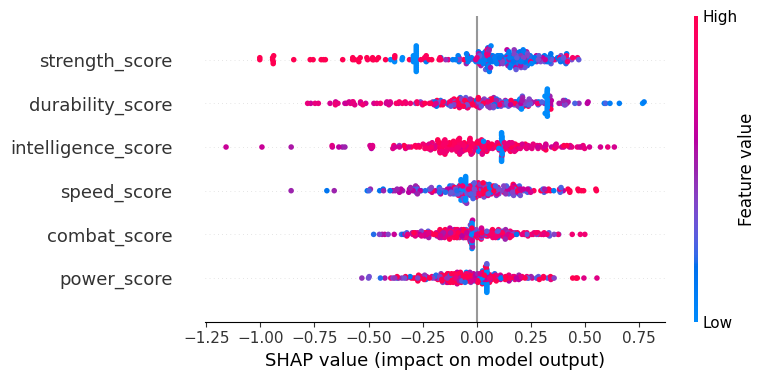

Instancia: 0
Clase predicha: Bad
Clase real: Bad


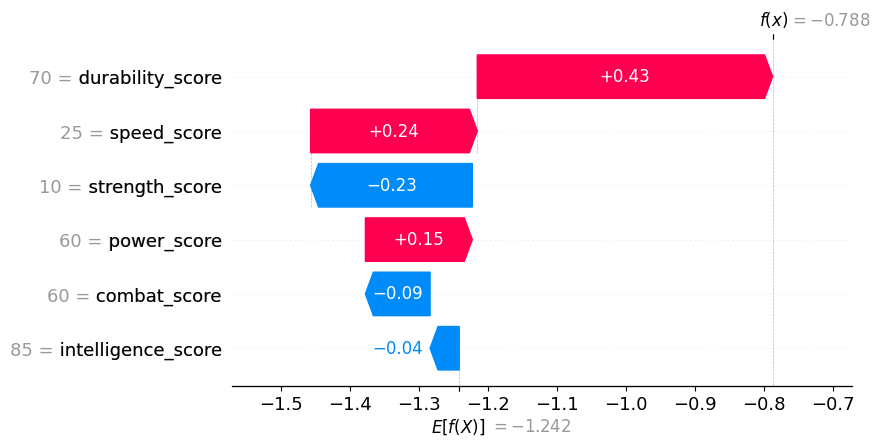

In [32]:
#### Código aquí ####

explainer = shap.TreeExplainer(lgbm_interp)
shap_values = explainer.shap_values(X_test_num)

classes = list(lgbm_interp.classes_)
good_idx = classes.index("Good")

if isinstance(shap_values, list):
    shap_values_good = shap_values[good_idx]
    base_value_good = explainer.expected_value[good_idx]
else:
    shap_values_good = shap_values[:, :, good_idx]
    base_value_good = explainer.expected_value[good_idx]

shap.summary_plot(
    shap_values_good,
    X_test_num,
    feature_names=NUMERICAL_FEATURES,
    class_names=classes,
)

idx = 0

pred_class = lgbm_interp.predict(X_test_num.iloc[[idx]])[0]
pred_idx = classes.index(pred_class)

if isinstance(shap_values, list):
    values_instance = shap_values[pred_idx][idx]
    base_value_instance = explainer.expected_value[pred_idx]
else:
    values_instance = shap_values[idx, :, pred_idx]
    base_value_instance = explainer.expected_value[pred_idx]

explanation = shap.Explanation(
    values=values_instance,
    base_values=base_value_instance,
    data=X_test_num.iloc[idx].values,
    feature_names=NUMERICAL_FEATURES,
)

print(f"Instancia: {idx}")
print(f"Clase predicha: {pred_class}")
print(f"Clase real: {y_test.iloc[idx] if hasattr(y_test, 'iloc') else y_test[idx]}")

shap.plots.waterfall(explanation)

### 4.2.3 Pregunta de Cierre [0.2 Puntos]

1. ¿Qué diferencia existe entre Permutation Feature Importance y los SHAP values como medida de importancia de features?
2. Según el `waterfall_plot`, ¿qué features fueron las que más empujaron la predicción hacia su clase? Investiga el personaje seleccionado: ¿Tiene sentido dado su historia en los cómics?

> **Respuesta:**

In [ ]:
# Escribe aquí la respuesta

Permutation Feature Importance y SHAP miden importancia de forma distinta. PFI es una medida global: permuta una variable en todo el conjunto de test y observa cuánto cambia el rendimiento del modelo, por ejemplo el F1-Macro. En cambio, SHAP entrega una explicación más local y detallada: muestra cuánto aporta cada feature a una predicción específica, indicando si empuja la predicción hacia una clase o la aleja de ella. Por eso PFI sirve más para ver qué variables son importantes en promedio, mientras que SHAP permite explicar casos individuales.

En el waterfall_plot de la instancia seleccionada, el modelo predijo la clase Bad y la clase real también era Bad. Las variables que más empujaron la predicción hacia esa clase fueron durability_score, speed_score y power_score, con aportes positivos de aproximadamente +0.43, +0.24 y +0.15 respectivamente. En cambio, strength_score, combat_score e intelligence_score empujaron en sentido contrario, especialmente strength_score con un aporte cercano a -0.23.

Esto sugiere que, para este personaje, el modelo asoció principalmente su alta durabilidad, velocidad y poder con la clase Bad. Sin embargo, la interpretación debe tomarse con cuidado, porque el modelo auxiliar solo usa atributos numéricos y no considera directamente la historia del personaje. En un problema de alineación moral, la historia y acciones del personaje probablemente son más informativas que sus habilidades físicas. Aun así, para esta instancia la explicación es consistente con la predicción: las variables positivas superaron a las negativas y llevaron al modelo a clasificarlo como Bad.

---

# 5. Predicción de Personajes No Etiquetados [0.5 Puntos]

<p align="center">
  <img src="https://pbs.twimg.com/media/DolotxUUYAAbg7f.jpg" width="350">
</p>

¡Llegó el momento de predecir `Vergil`, `Gorilla Girl` y `Bat-Cow`!

Usaremos el **mejor modelo** obtenido en la sección 3 (`pipe_lgbm_opt`) para predecir la alineación de los personajes no etiquetados.

**Nota:** Recuerda eliminar los NaN en `history_text` antes de predecir.

### 5.0 Predicción [0.2 Puntos]

**To-do:**
- [ ] Usar `pipe_lgbm_opt` para predecir `alignment` en `df_comics_no_label` (recuerda eliminar NaN en `history_text`).
- [ ] Filtrar y mostrar resultados para `Vergil`, `Gorilla Girl` y `Bat-Cow`.

In [33]:
#### Código aquí ####

df_no_label = df_comics_no_label.dropna(subset=["history_text"]).copy()

df_no_label["alignment_pred"] = pipe_lgbm_opt.predict(df_no_label)

target_names = ["Vergil", "Virgil", "Gorilla Girl", "Bat-Cow", "Batcow"]

results = df_no_label[
    df_no_label["name"]
    .str.lower()
    .str.replace("-", " ", regex=False)
    .isin([name.lower().replace("-", " ") for name in target_names])
]

results[["name", "real_name", "alignment_pred"]]

,name,real_name,alignment_pred
122,Batcow,NaN,Good
529,Gorilla Girl,Fahnbullah Eddy,Good
1368,Vergil,Vergil Sparda,Good
122,Batcow,NaN,Good


### 5.1 Análisis de Predicciones [0.3 Puntos]

**Pregunta:** Comenta las predicciones obtenidas para `Vergil`, `Gorilla Girl` y `Bat-Cow`:

1. ¿Las predicciones te parecen razonables según lo que conoces (o puedes inferir) de estos personajes?
2. Conecta con la sección 4: ¿qué features numéricas habrían influido más en la predicción de **Bat-Cow** según el `waterfall_plot`? ¿Es consistente con la predicción obtenida aquí?

> **Respuesta:**

In [27]:
# Escribe aquí la respuesta

El modelo predijo la clase Good para Batcow, Gorilla Girl y Vergil. En general, las predicciones parecen razonables para Batcow y Gorilla Girl, ya que se puede inferir que no son personajes principalmente villanos y que sus descripciones probablemente contienen señales asociadas a personajes heroicos o aliados. En el caso de Vergil, la predicción Good es más discutible, porque es un personaje con rasgos más ambiguos o de antihéroe, por lo que el modelo podría estar capturando palabras asociadas a protagonismo, poder o vínculo heroico más que una alineación moral estricta.

Respecto a la conexión con la sección 4, el waterfall_plot mostró que variables como durability_score, speed_score y power_score fueron las que más empujaron la predicción de la instancia analizada hacia su clase, mientras que strength_score, combat_score e intelligence_score empujaron en sentido contrario. Para Batcow, estas features numéricas podrían influir en la predicción si sus valores se parecen a perfiles que el modelo asocia con personajes Good. Sin embargo, hay que interpretar esto con cuidado, porque la predicción final usada en esta sección viene del modelo optimizado con texto e hiperparámetros, mientras que el waterfall de la sección 4 corresponde a un modelo auxiliar que solo usa variables numéricas.

# Conclusión

¡Eso ha sido todo para el lab de hoy! Recuerden que el laboratorio tiene un plazo de entrega de una semana y que **los días de atraso no se pueden utilizar para entregas de lab, solo para tareas**. Cualquier duda del laboratorio, no duden en contactarnos por mail o U-cursos.

<p align="center">
  <img src="https://media1.tenor.com/images/fb5bf7cc5a4acb91b4177672886a88ba/tenor.gif?itemid=5591338">
</p>